## Case Study

* **Michael suggested using a 1B model and running a small case study to determine fine-tuning speed on 1000 sentences from PubMedQA. From that, we can predict the time required for pre-training in general.**

In [1]:
!nvidia-smi

Wed Jan  7 12:36:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             53W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
%%capture
!pip install datasets sacremoses trl

In [3]:
import gc
import json
import torch
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset, DatasetDict
from tqdm import tqdm
from transformers import set_seed, AutoTokenizer, AutoModelForCausalLM
from trl import SFTTrainer, SFTConfig
from collections import defaultdict

In [4]:
def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
       torch.cuda.empty_cache()
       torch.cuda.ipc_collect()

set_seed(42)

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

print(f'on device: {device}')

on device: cuda:0


### PubMedQA

In [5]:
# split the PQA_Labeled data in ratio 9:0.5:0.5

pubmedqa = load_dataset('qiaojin/PubMedQA', 'pqa_labeled', split=['train'])[0].train_test_split(test_size=0.1)
pubmedqa_test = pubmedqa['test'].train_test_split(test_size=0.5)

ds_train, ds_val, ds_test = pubmedqa['train'].shuffle(), pubmedqa_test['train'].shuffle(), pubmedqa_test['test'].shuffle()

ds = DatasetDict(
    {
        'train': ds_train,
        'val': ds_val,
        'test': ds_test
    }
)

ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

pqa_labeled/train-00000-of-00001.parquet:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['pubid', 'question', 'context', 'long_answer', 'final_decision'],
        num_rows: 900
    })
    val: Dataset({
        features: ['pubid', 'question', 'context', 'long_answer', 'final_decision'],
        num_rows: 50
    })
    test: Dataset({
        features: ['pubid', 'question', 'context', 'long_answer', 'final_decision'],
        num_rows: 50
    })
})

### Model

In [6]:
class Model(object):
    def __init__(self, model_name_or_path):
        self.model_name_or_path = model_name_or_path
        self.tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
        self.model = AutoModelForCausalLM.from_pretrained(model_name_or_path, use_cache=False, dtype=torch.bfloat16).to(device)

        params = round(sum(p.numel() for p in self.model.parameters()) / (10 ** 9), 2)
        print(f'model loaded: {model_name_or_path} with params: {params}B')

    @staticmethod
    def inference(lm, test_prompts, inference_batch_size=4):
        lm.tokenizer.padding_side = "left"
        preds = []
        with torch.no_grad():

            lm.model.eval()
            lm.model.config.use_cache = True

            with torch.inference_mode():
                  for i in tqdm(range(0, len(test_prompts), inference_batch_size)):
                        batch_prompts = test_prompts[i : i + inference_batch_size]

                        inputs = lm.tokenizer(batch_prompts, return_tensors='pt', padding=True, truncation=True, pad_to_multiple_of=8, max_length=MAX_SOURCE_QA).to(lm.model.device)

                        out = lm.model.generate(
                                **inputs,
                                max_new_tokens=MAX_TARGET_QA,
                                do_sample=False,
                                use_cache=True,
                                eos_token_id=lm.tokenizer.eos_token_id,
                                pad_token_id=lm.tokenizer.pad_token_id,
                                return_dict_in_generate=False
                            )

                        gen = out[:, inputs['input_ids'].shape[-1] : ]
                        decoded = lm.tokenizer.batch_decode(gen, skip_special_tokens=True)

                        preds.extend([d.strip() for d in decoded])
        return preds

lm = Model('Qwen/Qwen3-8B')
# lm = Model('Qwen/Qwen2.5-1.5B')

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

...

model-00001-of-00005.safetensors:   0%|          | 0.00/4.00G [00:00<?, ?B/s]

model-00003-of-00005.safetensors:   0%|          | 0.00/3.96G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model loaded: Qwen/Qwen3-8B with params: 8.19B


### Hands-on with the dataset

iterating train dataset: 100%|██████████| 900/900 [00:01<00:00, 697.23it/s]


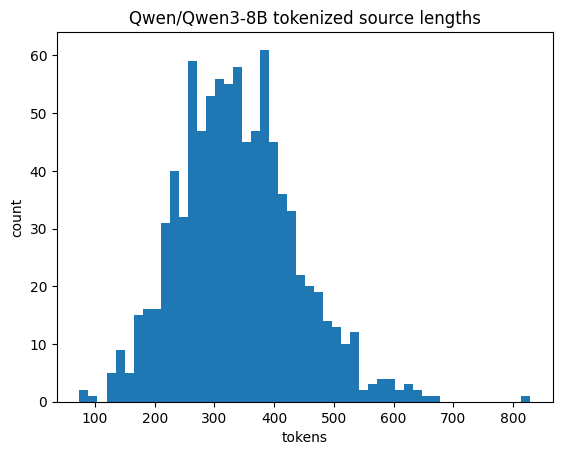

In [7]:
src_lengths, tgt_lengths = [], []

for row in tqdm(ds['train'], desc='iterating train dataset'):
    q, c = row['question'], '\n'.join(row['context']['contexts'])

    src = f'question: {q} context: {c}'
    tgt = row['final_decision']

    src_input_ids = lm.tokenizer(src).input_ids
    tgt_input_ids = lm.tokenizer(tgt).input_ids

    src_lengths.append(len(src_input_ids))
    tgt_lengths.append(len(tgt_input_ids))

src_lengths = np.array(src_lengths)
tgt_lengths = np.array(tgt_lengths)

# we do not really need to plot tgt lengths, since the final answer is a single token
plt.figure()
plt.hist(src_lengths, bins=50)
plt.title(f'{lm.model_name_or_path} tokenized source lengths')
plt.xlabel('tokens'); plt.ylabel('count')
plt.show()



In [8]:
pc = np.percentile(src_lengths, 95)
print(f'source QA 95%: {pc}')

# chosen based on the first power of 2, which covers the 95% of the src lengths
MAX_TARGET_QA = 1

base, power = 2, 1
while base ** power < pc:
      power += 1
MAX_SOURCE_QA = base ** power

print(f'src length: {MAX_SOURCE_QA} tgt length: {MAX_TARGET_QA}')

source QA 95%: 510.14999999999986
src length: 512 tgt length: 1


#### Y-axis

maybe: 0.1056%
no: 0.3311%
yes: 0.5633%


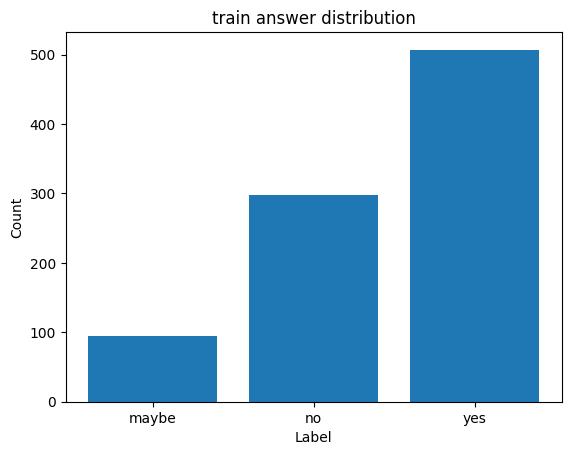

In [9]:
def plot_dist(data, label=''):

    keys, values = np.unique(data['final_decision'], return_counts=True)

    for idx, k in enumerate(keys):
      print(f'{k}: {round(values[idx] / sum(values), 4)}%')

    plt.figure()
    plt.bar(list(keys), list(values))
    plt.title(f'{label} answer distribution')
    plt.xlabel('Label'); plt.ylabel('Count')
    plt.show()

# change with 'val' and 'test'
plot_dist(ds['train'], label='train')

### SFT Fine-Tuning

In [11]:
lm.tokenizer.padding_side = "right"
lm.tokenizer.pad_token = lm.tokenizer.eos_token

In [12]:
def process_fn(b):
    d = {'prompt': [], 'completion': []}
    qs, cs, ans = b['question'], b['context'], b['final_decision']

    for q, c, a in zip(qs, cs, ans):
        c = '\n'.join(c['contexts'])

        src = f'Given the context:\n\n"{c}"\n\nAnswer the following question with a single word:\n\n"{q}"\n\nAnswer:\n\n'
        tgt = f' {a}'

        d['prompt'].append(src)
        d['completion'].append(tgt)

    return d

ds_sft = ds.map(process_fn, batched=True, batch_size=4, remove_columns=ds['train'].column_names, desc='Processing data')

ds_sft

DatasetDict({
    train: Dataset({
        features: ['prompt', 'completion'],
        num_rows: 900
    })
    val: Dataset({
        features: ['prompt', 'completion'],
        num_rows: 50
    })
    test: Dataset({
        features: ['prompt', 'completion'],
        num_rows: 50
    })
})

### Out-of-the-box inference

In [15]:
y_hat_init = Model.inference(lm, test_prompts=ds_sft['test']['prompt'], inference_batch_size=4)

print(y_hat_init[ : 10])
clear_memory()

100%|██████████| 13/13 [00:02<00:00,  6.21it/s]


['Yes', 'Based', 'Yes', 'Based', 'Based', 'Yes', 'Based', 'Based', 'Yes', 'Yes']


In [16]:
cfg = SFTConfig(
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=1,
    completion_only_loss=True,
    optim='adamw_torch_fused',
    max_length=MAX_SOURCE_QA,
    pad_to_multiple_of=8,
    learning_rate=1e-5,
    max_grad_norm=1.0,
    gradient_checkpointing=True,
    report_to='none',
    run_name=None,
    logging_strategy='epoch',
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=1,
    load_best_model_at_end=True
)

trainer = SFTTrainer(
    model=lm.model,
    args=cfg,
    train_dataset=ds_sft['train'],
    eval_dataset=ds_sft['val'],
    processing_class=lm.tokenizer)

# epoch is too much, but the goal is to measure runtime
trainer.train()

Adding EOS to train dataset:   0%|          | 0/900 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/900 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/900 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.826800,0.449884,1.282260,314789.000000,0.845238
2,0.198300,0.519940,1.246203,629578.000000,0.845238


TrainOutput(global_step=226, training_loss=0.5125579412004589, metrics={'train_runtime': 685.2766, 'train_samples_per_second': 2.627, 'train_steps_per_second': 0.33, 'total_flos': 3.924333293587661e+16, 'train_loss': 0.5125579412004589, 'epoch': 2.0})

### Eval

- you can also load a model for inference (especially if you connect your GDrive), however, this is intended to all run within the same session.

In [18]:
y_hat = Model.inference(lm, test_prompts=ds_sft['test']['prompt'], inference_batch_size=4)

y_hat[ : 10]

100%|██████████| 13/13 [00:02<00:00,  6.13it/s]


['yes', 'no', 'yes', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'yes']

##### Gold Standard

In [19]:
list(ds_sft['test']['completion'])[ : 10]

[' yes', ' no', ' yes', ' maybe', ' no', ' yes', ' no', ' no', ' yes', ' yes']

In [20]:
clear_memory()

### Discussion

1. This notebook fine-tunes **Qwen/Qwen2.5-1.5B** and **Qwen/Qwen3-8B** on 900 PubMedQA questions
2. Uses the standard prompt-completion format and the SFT Trainer
3. **Qwen/Qwen2.5-1.5B** - ran on a A100 40GBs for 2 epochs ~ 142 seconds. Uses 19.5GB RAM.
4. **Qwen/Qwen3-8B** - ran on a A100 80GBs for 2 epochs ~ 685 seconds. Uses 66GB RAM. Better choice might be to consider SFT + PEFT
5. The focus is not what happens in the fine-tuning itself, but rather on the hardware constraints for performing it, so there is no formal evaluation.
